In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
# from scikit_posthocs import posthoc_dunn
# from scipy.stats import f_oneway, kruskal
import scipy.stats as st
# from statannotations.Annotator import Annotator
import statsmodels.api as sm
import matplotlib.colors as mcolors


# sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size
sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')




# Analyse CFU data from community assembly 1
Correlations, rank distributions etc

In [2]:
repo_folder = Path("../..")
gp_folder = repo_folder / 'data/1_growth_phenotyping'
figure_folder = repo_folder / "Figures" / "2_community_assembly"
figure_folder.mkdir(parents=True, exist_ok=True)


## Read in data

In [3]:
data_folder = Path("../../data/2_first_community_assembly")
file_to_open = data_folder / "cfus.csv"
df = pd.read_csv(file_to_open, index_col=0)

In [4]:
wellmap_fn = data_folder / "wellmap.csv"
wellmap_df = pd.read_csv(wellmap_fn, index_col=0)
wellmap_df['Carbon source'] = wellmap_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
well_to_cs = wellmap_df.set_index('Well').to_dict()['Carbon source']
well_to_rep = wellmap_df.set_index('Well').to_dict()['Replicate']

In [5]:
shannon_df = pd.read_csv(data_folder / 'shannon_index.csv', index_col=0)

In [6]:
well_to_shannon = shannon_df['Shannon index'].to_dict()

In [7]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [8]:
strains = ['At', 'Ct', 'Ml', 'Oa']

In [9]:
df['Carbon source'] = df['Carbon source'].str.replace('L-', '').str.replace('D-','')
df = df.loc[df['Carbon source'].notna()]

In [10]:
cs_class_fn = gp_folder / 'selected_carbon_sources.csv'
cs_class_df = pd.read_csv(cs_class_fn)
cs_class_df.rename(columns={'Metabolite name': 'Carbon source'}, inplace=True)
cs_class_df['Carbon source'] = cs_class_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

cs_class_df.replace({'Metabolite class': {'Alcohol': 'Other', 'Nucleoside': 'Other', 'Simple sugar':'Sugar'}}, inplace=True)
cs_to_class = cs_class_df.set_index('Carbon source').to_dict()['Metabolite class']

well_to_class = {}
for well, cs in well_to_cs.items():
    if cs == 'No CS':
        well_to_class[well] = 'No CS'
    else:
        try:
            well_to_class[well] = cs_to_class[cs]
        except KeyError:
            well_to_class[well] = 'Mix'

# well_to_cs_type = {well:cs_to_cs_type[cs] for well, cs in cs_class_df.items() if not '+' in cs and not (cs == 'No CS')}

# Read in growth data

In [11]:


rate_df = pd.read_csv(gp_folder / 'fitted_growth_parameters.csv', index_col=0)
rate_df['Carbon source'] = rate_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
rate_df['# CS'] = 1
rate_df.loc[rate_df['Carbon source'] == 'No cs', '# CS'] = 0
rate_df.replace({'max_growth_rate':{np.nan:0}}, inplace=True)



In [12]:
# rate_df.replace({'lag':{np.nan:0}}, inplace=True)
# rate_df.replace({'Yield':{np.nan:1}}, inplace=True)
# rate_df.replace({'y0':{np.nan:1}}, inplace=True)

In [13]:
# lag_flag = True
# if lag_flag:
rate_df["Effective growth rate"] = rate_df["max_growth_rate"]*(np.log(rate_df["Yield"]) - np.log(rate_df["y0"]))/(rate_df["max_growth_rate"]*rate_df["lag"] + np.log(rate_df["Yield"]/rate_df["y0"]))

/Users/snorre/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [14]:
rate_df.replace({'max_growth_rate':{np.nan:0}, 'Effective growth rate': {np.nan: 0}}, inplace=True)

In [15]:
# First, calculate the max growth rate of the carbon source pairs as the sume of the growthr ate on the individuals
double_cs = sorted([x for x in df['Carbon source'].unique() if '+' in x])
double_rates = []
for cs_pair in double_cs:
    cs1, cs2 = cs_pair.split(' + ')
    for strain in strains:
        rate1 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs1), 'max_growth_rate'].values[0]
        rate2 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs2), 'max_growth_rate'].values[0]
        erate1 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs1), 'Effective growth rate'].values[0]
        erate2 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs2), 'Effective growth rate'].values[0]
        double_rates.append({'Species': strain, 'Carbon source': cs_pair, 'max_growth_rate': rate1 + rate2, 'Effective growth rate': erate1 + erate2})
double_rate_df = pd.DataFrame(double_rates)
double_rate_df['# CS'] = 2
rate_df = pd.concat([rate_df, double_rate_df])

## Compute rank

In [16]:
df_mean78 = df.loc[df.Batch.isin([7, 8])].groupby(['Strain', 'Carbon source']).agg({'CFUs/mL':['mean', 'std']}).reset_index()    

# Group by 'Carbon source' and rank species by abundance
df_mean78[('Abundance rank', '')] = df_mean78.groupby([('Carbon source', '')]).rank(ascending=False, method='min')[( 'CFUs/mL', 'mean')]
df_mean78.columns = ['Species', 'Carbon source', 'Mean CFUs/mL', 'Std CFUs/mL', 'Abundance rank']



In [17]:
df_log = df.copy()
df_log['log10(CFUs/mL)'] = np.log10(df_log['CFUs/mL'])
df_logmean78 = df_log.loc[df_log.Batch.isin([7, 8])].groupby(['Strain', 'Carbon source']).agg({'log10(CFUs/mL)':['mean', 'std']}).reset_index()    
df_logmean78[('Abundance rank', '')] = df_logmean78.groupby([('Carbon source', '')]).rank(ascending=False, method='min')[( 'log10(CFUs/mL)', 'mean')]
df_logmean78.columns = ['Species', 'Carbon source', 'Mean log10(CFUs/mL)', 'Std log10(CFUs/mL)', 'Abundance rank']

### Rank from monoculture data

In [18]:
rate_df['Growth rate rank'] = rate_df[['Carbon source','Species','max_growth_rate']].groupby('Carbon source').rank(ascending=False, method='min')['max_growth_rate']
rate_df['Effective growth rate rank'] = rate_df[['Carbon source','Species','Effective growth rate']].groupby('Carbon source').rank(ascending=False, method='min')['Effective growth rate']

In [19]:
df_mean78 = pd.merge(left = df_mean78, right = rate_df[['Carbon source', 'Growth rate rank', 'Species', 'max_growth_rate', '# CS', 'Effective growth rate', 'Effective growth rate rank']], on = ['Carbon source', 'Species'], how = 'left')
df_logmean78 = pd.merge(left = df_logmean78, right = rate_df[['Carbon source', 'Growth rate rank', 'Species', 'max_growth_rate', '# CS', 'Effective growth rate', 'Effective growth rate rank']], on = ['Carbon source', 'Species'], how = 'left')

In [85]:
df_logmean78_nocs = df_logmean78.loc[df_logmean78['Carbon source'] == 'No CS']

In [86]:
df_mean78 = df_mean78.loc[df_mean78['# CS'].isin([1,2])]
df_logmean78 = df_logmean78.loc[df_logmean78['# CS'].isin([1,2])]

In [87]:
df_mean78.loc[~df_mean78['Growth rate rank'].notna()]

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank,Prediction diff


In [89]:
# nanidx = df_mean78['Growth rate rank'].notna()
# print(st.spearmanr(df_mean78.loc[nanidx, 'Growth rate rank'], df_mean78.loc[nanidx, 'Abundance rank']))
# print(st.pearsonr(df_mean78.loc[nanidx, 'Growth rate rank'], df_mean78.loc[nanidx, 'Abundance rank']))

# # st.pearsonr(df_mean78.loc[~nanidx, 'Abundance rank'], df_mean78.loc[~nanidx, 'Growth rate rank'])

In [90]:
# idx1 = nanidx & (df_mean78['# CS'] == 1)
# idx2 = nanidx & (df_mean78['# CS'] == 2)
# print(st.spearmanr(df_mean78.loc[idx1, 'Growth rate rank'], df_mean78.loc[idx1, 'Abundance rank']))
# print(st.spearmanr(df_mean78.loc[idx2, 'Growth rate rank'], df_mean78.loc[idx2, 'Abundance rank']))


# Create adjusted abundance rank prediction from growth rate ranks


In [24]:
auxotrophs = ['Oa', 'Ml']
prototrophs = ['At', 'Ct']
for i, cs in enumerate(df_mean78['Carbon source'].unique()):
    df_cs = df_mean78[df_mean78['Carbon source'] == cs].copy()
    df_cs.sort_values('Effective growth rate rank', inplace=True)
    j=0
    while j<4:
        if df_cs.iloc[j]['Species'] in prototrophs:
            break
        j+=1 
    # if j == 0:
    # print(cs, j)
    
    for k, (idx, row) in enumerate(df_cs.iterrows()):
        if k<j:
            df_mean78.at[idx, 'Predicted rank'] = row['Effective growth rate rank']+1
        elif k == j:
            df_mean78.at[idx, 'Predicted rank'] = 1
        else:
            df_mean78.at[idx, 'Predicted rank'] = row['Effective growth rate rank']

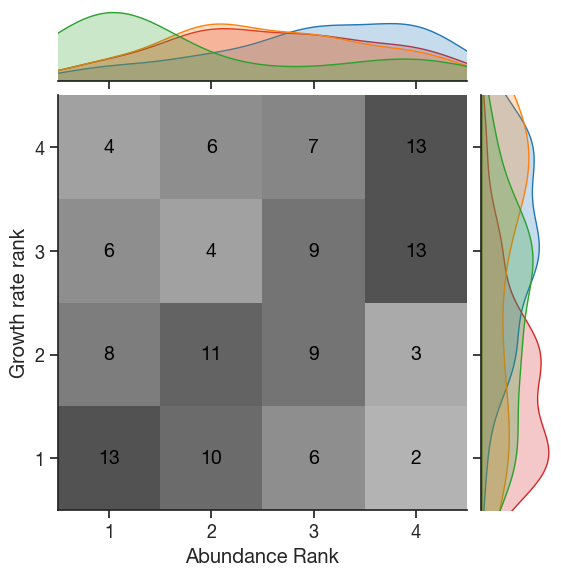

In [94]:

species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot

idx = df_logmean78['# CS'].isin([1,2])
# Create a jointplot for the current species
g = sns.JointGrid(
    data=df_logmean78.loc[idx],
    x='Abundance rank',
    y='Growth rate rank',
    # kind='hist',  # Use KDE for the main plot
    # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
    # bins=4,
    # height=6,
    # ratio=5

    # dropna=True,
    # discrete=(True, True),
    
    # fill=True,  # Fill the KDE plot
    # color = palette[i],
    # cmap = cmap,
    # cbar=True,  # Add
    # thresh=None,
    # cbar_kws=dict(shrink=.75)
    # cmap='viridis'  # Choose a colormap
)
g.plot_joint(sns.histplot, discrete=(True, True), bins = 4, color = 'gray')  
g.plot_marginals(sns.kdeplot, palette=palette, fill=True, hue='Species', hue_order=species_list,data=df_logmean78.loc[idx], common_grid=True, common_norm=False)

    # Add a regression line to the main axes
# sns.regplot(
#     data=species_data,
#     x='Abundance rank',
#     y='Growth rate rank',
#     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
#     ax=g.ax_joint,
#     color='black',  # Color of the regression line
#     line_kws={'linewidth': 2}  # Customize the regression line
# )
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(0.5, 4.5)
g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# Customize the plot
g.ax_joint.set_xlabel('Abundance Rank')
g.ax_joint.set_ylabel('Growth rate rank')

    # g.ax_joint.set_title(f'Jointplot: {species}')
    # Annotate each square with the count
hist_data, x_edges, y_edges = np.histogram2d(
    df_logmean78.loc[idx, 'Abundance rank'],
    df_logmean78.loc[idx, 'Growth rate rank'],
    bins=4
)

# Loop through the bins and annotate
for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        # Compute the center of each bin
        x = (x_edges[i] + x_edges[i + 1]) / 2
        y = (y_edges[j] + y_edges[j + 1]) / 2
        count = int(hist_data[i, j])
        if count > 0:  # Only annotate non-empty bins
            g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

plt.savefig(figure_folder / 'growth_rate_rank_vs_abundance_rank.pdf')



In [93]:
print((df_mean78['Growth rate rank'] == df_mean78['Abundance rank']).sum())
print((df_logmean78['Growth rate rank'] == df_logmean78['Abundance rank']).sum())

47
46


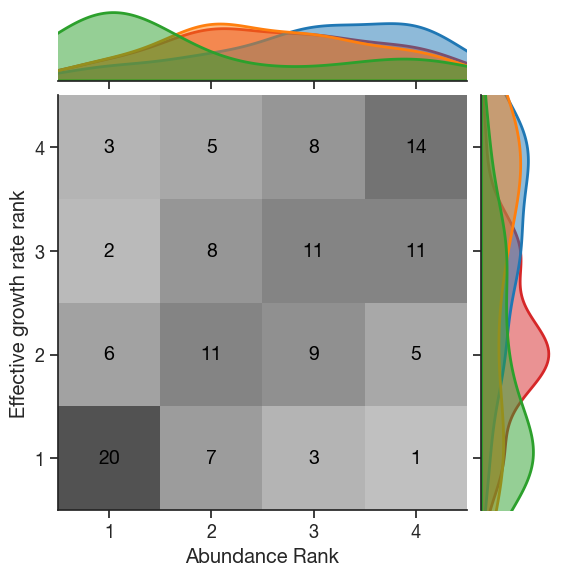

In [95]:

species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot

idx = df_logmean78['# CS'].isin([1,2])
# Create a jointplot for the current species
g = sns.JointGrid(
    data=df_logmean78.loc[idx],
    x='Abundance rank',
    y='Effective growth rate rank',
    # kind='hist',  # Use KDE for the main plot
    # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
    # bins=4,
    # height=6,
    # ratio=5

    # dropna=True,
    # discrete=(True, True),
    
    # fill=True,  # Fill the KDE plot
    # color = palette[i],
    # cmap = cmap,
    # cbar=True,  # Add
    # thresh=None,
    # cbar_kws=dict(shrink=.75)
    # cmap='viridis'  # Choose a colormap
)
g.plot_joint(sns.histplot, discrete=(True, True), bins = 4, color = 'gray')  
g.plot_marginals(sns.kdeplot, palette=palette, fill=True, hue='Species', hue_order=species_list,data=df_logmean78.loc[idx], common_grid=True, common_norm=False, lw = 2, alpha = 0.5)

    # Add a regression line to the main axes
# sns.regplot(
#     data=species_data,
#     x='Abundance rank',
#     y='Growth rate rank',
#     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
#     ax=g.ax_joint,
#     color='black',  # Color of the regression line
#     line_kws={'linewidth': 2}  # Customize the regression line
# )
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(0.5, 4.5)
g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# Customize the plot
g.ax_joint.set_xlabel('Abundance Rank')
g.ax_joint.set_ylabel('Effective growth rate rank')

    # g.ax_joint.set_title(f'Jointplot: {species}')
    # Annotate each square with the count
hist_data, x_edges, y_edges = np.histogram2d(
    df_logmean78.loc[idx, 'Abundance rank'],
    df_logmean78.loc[idx, 'Effective growth rate rank'],
    bins=4
)

# Loop through the bins and annotate
for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        # Compute the center of each bin
        x = (x_edges[i] + x_edges[i + 1]) / 2
        y = (y_edges[j] + y_edges[j + 1]) / 2
        count = int(hist_data[i, j])
        if count > 0:  # Only annotate non-empty bins
            g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

plt.savefig(figure_folder / 'growth_rate_rank_vs_abundance_rank.pdf')



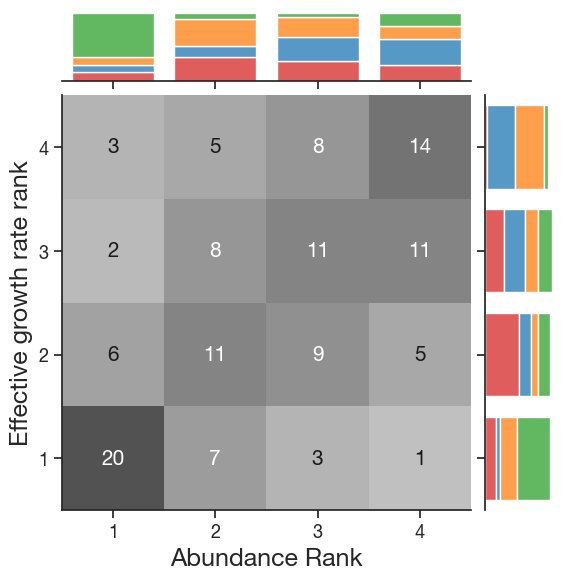

In [96]:
# Similar plot with stacked bar charts on marginals
idx = df_logmean78['# CS'].isin([1,2])

g = sns.JointGrid(
    data=df_logmean78.loc[idx],
    x='Abundance rank',
    y='Effective growth rate rank',
)

# Plot main 2D histogram
g.plot_joint(sns.histplot, discrete=(True, True), bins=4, color='gray')

# Plot marginals as stacked bar charts
g.plot_marginals(
    sns.histplot, 
    hue='Species', 
    hue_order=species_list,
    palette=palette,
    data=df_logmean78.loc[idx],
    multiple='stack',
    discrete=True,
    bins=4,
    shrink=0.8
)

# Customize axes
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(0.5, 4.5)
g.ax_joint.set_yticks([1, 2, 3, 4])
g.ax_joint.set_xticks([1, 2, 3, 4])

g.ax_joint.set_xlabel('Abundance Rank', fontdict={'size':18})
g.ax_joint.set_ylabel('Effective growth rate rank', fontdict={'size':18})

# Annotate with counts
hist_data, x_edges, y_edges = np.histogram2d(
    df_logmean78.loc[idx, 'Abundance rank'],
    df_logmean78.loc[idx, 'Effective growth rate rank'],
    bins=4
)

for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        x = (x_edges[i] + x_edges[i + 1]) / 2
        y = (y_edges[j] + y_edges[j + 1]) / 2
        count = int(hist_data[i, j])
        if count > 0:
            if count > 6:
                color = 'w'
            else:
                color = 'k'
            g.ax_joint.text(i+1, j+1, count, ha='center', va='center', 
                          fontsize=15, color=color, fontdict={'weight': 'bold'})

plt.savefig(figure_folder / 'growth_rate_rank_vs_abundance_rank_stacked_marginals.pdf')
plt.show()

In [97]:
df_logmean78.to_csv(data_folder / 'df_logmean78.csv')

In [99]:



# species_list = ['At', 'Ct', 'Ml', 'Oa']
# # Define a discrete colormap
# cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
# norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# # Loop through each species and create a jointplot

# idx = df_mean78['# CS'].isin([1])
# # Create a jointplot for the current species
# g = sns.JointGrid(
#     data=df_mean78.loc[idx],
#     x='Abundance rank',
#     y='Predicted rank',
  
# )
# g.plot_joint(sns.histplot, discrete=(True, True), bins = 4, color = 'gray')  
# g.plot_marginals(sns.kdeplot, palette=palette, fill=True, hue='Species', hue_order=species_list,data=df_mean78.loc[idx], common_grid=True, common_norm=False)

# g.ax_joint.set_xlim(0.5, 4.5)
# g.ax_joint.set_ylim(0.5, 4.5)
# g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# # Customize the plot
# g.ax_joint.set_xlabel('Abundance rank')
# g.ax_joint.set_ylabel('Growth prediction')
#     # g.ax_joint.set_title(f'Jointplot: {species}')
#     # Annotate each square with the count
# hist_data, x_edges, y_edges = np.histogram2d(
#     df_mean78.loc[idx, 'Abundance rank'],
#     df_mean78.loc[idx, 'Predicted rank'],
#     bins=4
# )

# # Loop through the bins and annotate
# for i in range(len(x_edges) - 1):
#     for j in range(len(y_edges) - 1):
#         # Compute the center of each bin
#         x = (x_edges[i] + x_edges[i + 1]) / 2
#         y = (y_edges[j] + y_edges[j + 1]) / 2
#         count = int(hist_data[i, j])
#         if count > 0:  # Only annotate non-empty bins
#             g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

# plt.savefig(figure_folder / 'predicted_rank_vs_abundance_rank.pdf')


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_31404/2154250320.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_31404/2154250320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


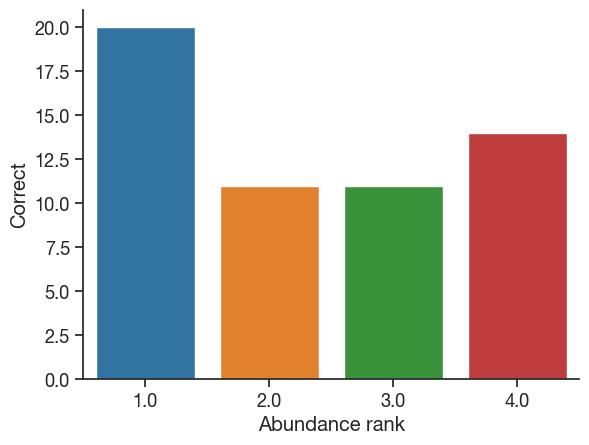

In [100]:
# Plot a small bar chart showin the number of correct predictions for each abundance rank
idxc = df_logmean78['Abundance rank'] == df_logmean78['Effective growth rate rank']
correct_df = df_logmean78.loc[idxc].groupby(['Abundance rank']).size()
sns.barplot(
    data=correct_df.reset_index(name='Correct'),
    x='Abundance rank',
    y='Correct',
    # hue = '# CS',
    estimator=np.mean,
    ci=None,
    palette = 'tab10'
    # color='gray'
)
sns.despine()

In [35]:
idx = df_mean78['# CS'].isin([1,2])

correct_pred = (df_mean78.loc[idx, 'Predicted rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
correct_growth = (df_mean78.loc[idx, 'Growth rate rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
correct_egrowth = (df_mean78.loc[idx, 'Effective growth rate rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
total = len(df_mean78.loc[idx])
print(f'Correctly predicted: {correct_pred}/{total} ({correct_pred/total:.2f})')
print(f'Correctly growth: {correct_growth}/{total} ({correct_growth/total:.2f})')
print(f'Correctly egrowth: {correct_egrowth}/{total} ({correct_egrowth/total:.2f})')

mad_pred = (df_mean78.loc[idx, 'Predicted rank'] - df_mean78.loc[idx, 'Abundance rank']).abs().sum()/total
mad_growth = (df_mean78.loc[idx, 'Growth rate rank'] - df_mean78.loc[idx, 'Abundance rank']).abs().sum()/total
print(f'MAD predicted: {mad_pred:.2f}')
print(f'MAD growth: {mad_growth:.2f}')

Correctly predicted: 61/124 (0.49)
Correctly growth: 47/124 (0.38)
Correctly egrowth: 57/124 (0.46)
MAD predicted: 0.73
MAD growth: 0.89


In [102]:
idx = df_logmean78['# CS'].isin([1,2])

correct_growth = (df_logmean78.loc[idx, 'Growth rate rank'] == df_logmean78.loc[idx, 'Abundance rank']).sum()
correct_egrowth = (df_logmean78.loc[idx, 'Effective growth rate rank'] == df_logmean78.loc[idx, 'Abundance rank']).sum()
total = len(df_logmean78.loc[idx])
print(f'Correctly growth: {correct_growth}/{total} ({correct_growth/total:.2f})')
print(f'Correctly egrowth: {correct_egrowth}/{total} ({correct_egrowth/total:.2f})')

mad_growth = (df_logmean78.loc[idx, 'Growth rate rank'] - df_logmean78.loc[idx, 'Abundance rank']).abs().sum()/total
print(f'MAD growth: {mad_growth:.2f}')

Correctly growth: 46/124 (0.37)
Correctly egrowth: 56/124 (0.45)
MAD growth: 0.90


In [103]:
# Correlations
# print('Growth rate', st.pearsonr(df_mean78.loc[idx, 'Growth rate rank'], df_mean78.loc[idx, 'Abundance rank']))
# print('Effective groth rate', st.pearsonr(df_mean78.loc[idx, 'Effective growth rate rank'], df_mean78.loc[idx, 'Abundance rank']))

In [107]:
# Correlations
print("Kendall's tau")
# print('Growth rate', st.kendalltau(df_mean78['Growth rate rank'], df_mean78['Abundance rank']))
# print('Effective groth rate', st.kendalltau(df_mean78['Effective growth rate rank'], df_mean78['Abundance rank']))

print('Growth rate', st.kendalltau(df_logmean78['Growth rate rank'], df_logmean78['Abundance rank']))
print('Effective groth rate', st.kendalltau(df_logmean78['Effective growth rate rank'], df_logmean78['Abundance rank']))


Kendall's tau
Growth rate SignificanceResult(statistic=np.float64(0.32729164983018083), pvalue=np.float64(1.3353539136478885e-05))
Effective groth rate SignificanceResult(statistic=np.float64(0.4572023258889013), pvalue=np.float64(1.182943285575703e-09))


In [108]:
# idx1 = df_mean78['# CS'] == 1
# correct_pred = (df_mean78.loc[idx1, 'Predicted rank'] == df_mean78.loc[idx1, 'Abundance rank']).sum()
# correct_growth = (df_mean78.loc[idx1, 'Growth rate rank'] == df_mean78.loc[idx1, 'Abundance rank']).sum()
# total = len(df_mean78.loc[idx1])
# print(f'Correctly predicted: {correct_pred}/{total} ({correct_pred/total:.2f})')
# print(f'Correctly growth: {correct_growth}/{total} ({correct_growth/total:.2f})')

# mad_pred = (df_mean78.loc[idx1, 'Predicted rank'] - df_mean78.loc[idx1, 'Abundance rank']).abs().sum()/total
# mad_growth = (df_mean78.loc[idx1, 'Growth rate rank'] - df_mean78.loc[idx1, 'Abundance rank']).abs().sum()/total
# print(f'MAD predicted: {mad_pred:.2f}')
# print(f'MAD growth: {mad_growth:.2f}')

In [109]:
# idx1 = df_mean78['# CS'] == 2
# correct_pred = (df_mean78.loc[idx1, 'Predicted rank'] == df_mean78.loc[idx1, 'Abundance rank']).sum()
# correct_growth = (df_mean78.loc[idx1, 'Growth rate rank'] == df_mean78.loc[idx1, 'Abundance rank']).sum()
# total = len(df_mean78.loc[idx1])
# print(f'Correctly predicted: {correct_pred}/{total} ({correct_pred/total:.2f})')
# print(f'Correctly growth: {correct_growth}/{total} ({correct_growth/total:.2f})')

# mad_pred = (df_mean78.loc[idx1, 'Predicted rank'] - df_mean78.loc[idx1, 'Abundance rank']).abs().sum()/total
# mad_growth = (df_mean78.loc[idx1, 'Growth rate rank'] - df_mean78.loc[idx1, 'Abundance rank']).abs().sum()/total
# print(f'MAD predicted: {mad_pred:.2f}')
# print(f'MAD growth: {mad_growth:.2f}')

In [111]:
# for abundance_rank in [1,2,3,4]:
#     idx = (df_mean78['# CS'].isin([1,2])) & (df_mean78['Abundance rank'] == abundance_rank)
#     correct_pred = (df_mean78.loc[idx, 'Predicted rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
#     total = len(df_mean78.loc[idx])
#     print(f'Correctly predicted ({abundance_rank}): {correct_pred}/{total} ({correct_pred/total:.2f})')

In [112]:
# df_mean78['Prediction diff'] = (df_mean78['Predicted rank'] - df_mean78['Abundance rank'])
# df_mean78.groupby('Species')['Prediction diff'].agg(['mean', 'std'])

# PCA

In [44]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [45]:
df_mean78w = df.loc[df.Batch.isin([7,8])].groupby(['Well', 'Strain']).agg({'CFUs/mL':['mean', 'std'], 'Carbon source':'first'}).reset_index()
# df_mean78w.rename({'Strain':'Species'}, inplace = True)
df_mean78w.columns = ['Well', 'Species', 'Mean CFUs/mL', 'Std CFUs/mL', 'Carbon source']
df_mean78w['CS class'] = df_mean78w['Carbon source'].map(cs_to_class)
df_mean78w = pd.merge(left = df_mean78w, right = rate_df[['Carbon source', 'Growth rate rank', 'Species', 'max_growth_rate', '# CS', 'Effective growth rate', 'Effective growth rate rank']], on = ['Carbon source', 'Species'], how = 'left')


df_mean78w = df_mean78w.loc[df_mean78w['# CS'].isin([1,2])]

idx1 = df_mean78w['# CS'] == 1
idx2 = df_mean78w['# CS'] == 2


cfu_data = df_mean78w.pivot(index = ['Well'], columns = 'Species', values = 'Mean CFUs/mL')
cfu_data1 = df_mean78w.loc[idx1].pivot(index = ['Well'], columns = 'Species', values = 'Mean CFUs/mL')
# cfu_data.fillna(0, inplace=True)

# cfu_data.drop(index=['H10', 'H11', 'H12'], inplace=True)
cfu_data.reset_index()
log_cfu = np.log10(cfu_data)
log_cfu1 = np.log10(cfu_data1)


In [46]:
# Find the most abundant species for each well
most_abundant_species = df_mean78w.groupby('Well')['Mean CFUs/mL'].idxmax()

# Create a dictionary mapping wells to the most abundant species
well_to_aspecies = {
    well: df_mean78w.loc[idx, 'Species'] for well, idx in most_abundant_species.items()
}

# Display the resulting dictionary
print(well_to_aspecies)

df_mean78w['Abundance rank'] = df_mean78w.groupby(['Well']).rank(ascending=False, method='min')['Mean CFUs/mL']
well_to_at_rank = df_mean78w.loc[df_mean78w.Species=='At'].set_index('Well').to_dict()['Abundance rank']
well_to_ct_rank = df_mean78w.loc[df_mean78w.Species=='Ct'].set_index('Well').to_dict()['Abundance rank']
well_to_ml_rank = df_mean78w.loc[df_mean78w.Species=='Ml'].set_index('Well').to_dict()['Abundance rank']
well_to_oa_rank = df_mean78w.loc[df_mean78w.Species=='Oa'].set_index('Well').to_dict()['Abundance rank']


{'A1': 'Oa', 'A10': 'Oa', 'A11': 'Oa', 'A12': 'Oa', 'A2': 'At', 'A3': 'Oa', 'A4': 'At', 'A5': 'At', 'A6': 'At', 'A7': 'Oa', 'A8': 'Oa', 'A9': 'Oa', 'B1': 'At', 'B10': 'Ct', 'B11': 'Ct', 'B12': 'Ct', 'B2': 'At', 'B3': 'At', 'B4': 'At', 'B5': 'At', 'B6': 'At', 'B7': 'At', 'B8': 'At', 'B9': 'At', 'C1': 'At', 'C10': 'At', 'C11': 'At', 'C12': 'At', 'C2': 'At', 'C3': 'Oa', 'C4': 'Ct', 'C5': 'Ct', 'C6': 'Ct', 'C7': 'Oa', 'C8': 'Ml', 'C9': 'Ml', 'D1': 'At', 'D10': 'At', 'D11': 'At', 'D12': 'At', 'D2': 'At', 'D3': 'At', 'D4': 'At', 'D5': 'At', 'D6': 'At', 'D7': 'At', 'D8': 'At', 'D9': 'At', 'E1': 'At', 'E10': 'Ml', 'E11': 'Ml', 'E12': 'Ml', 'E2': 'At', 'E3': 'At', 'E4': 'Ct', 'E5': 'Ct', 'E6': 'Ct', 'E7': 'Ml', 'E8': 'Ml', 'E9': 'Ct', 'F1': 'Oa', 'F10': 'At', 'F11': 'At', 'F12': 'At', 'F2': 'Oa', 'F3': 'Oa', 'F4': 'At', 'F5': 'At', 'F6': 'At', 'F7': 'At', 'F8': 'At', 'F9': 'At', 'G1': 'At', 'G10': 'At', 'G11': 'At', 'G12': 'At', 'G2': 'At', 'G3': 'At', 'G4': 'At', 'G5': 'At', 'G6': 'At', 'G7': 

In [47]:
# Standardize the data
scaler = StandardScaler()
cfu_data_scaled = scaler.fit_transform(log_cfu)

# Perform PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_result = pca.fit_transform(cfu_data_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=cfu_data.index)
pca_df.columns = ['Principal component 1', 'Principal component 2']
pca_df['Carbon source class'] = pca_df.index.get_level_values('Well').map(well_to_class)
pca_df['Carbon source'] = pca_df.index.get_level_values('Well').map(well_to_cs)
pca_df['N CS'] = [2 if '+' in x else 1 for x in pca_df['Carbon source']]
pca_df['Most abundant species'] = pca_df.index.map(well_to_aspecies)
pca_df['At rank'] = pca_df.index.map(well_to_at_rank).astype(int)
pca_df['Ct rank'] = pca_df.index.map(well_to_ct_rank).astype(int)
pca_df['Ml rank'] = pca_df.index.map(well_to_ml_rank).astype(int)
pca_df['Oa rank'] = pca_df.index.map(well_to_oa_rank).astype(int)
pca_df['At r'] = pca_df['Carbon source'].map(rate_df.loc[rate_df.Species=='At'].set_index('Carbon source').to_dict()['max_growth_rate'])
pca_df['Ct r'] = pca_df['Carbon source'].map(rate_df.loc[rate_df.Species=='Ct'].set_index('Carbon source').to_dict()['max_growth_rate']) 

In [48]:
pca_fit= pca.fit(cfu_data_scaled)
print(log_cfu.columns, pca_fit.components_, pca_fit.explained_variance_ratio_)

Index(['At', 'Ct', 'Ml', 'Oa'], dtype='object', name='Species') [[ 0.61720745 -0.56762937 -0.47267014 -0.27098858]
 [ 0.1609331  -0.40580501  0.19378365  0.87856174]] [0.50184996 0.2440325 ]


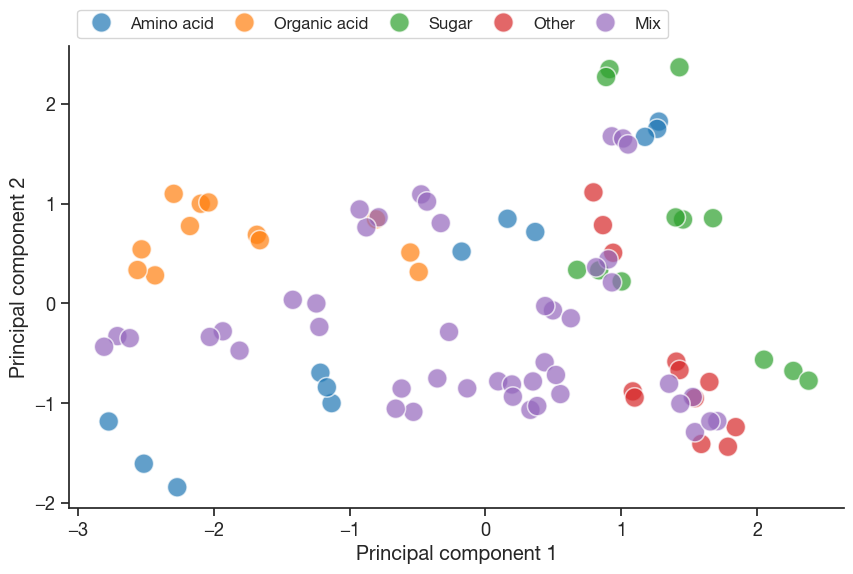

In [49]:
fig, ax = plt.subplots(figsize=(10,6))

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Carbon source class', s = 200, alpha = 0.7, 
                    hue_order=['Amino acid', 'Organic acid', 'Sugar', 'Other', 'Mix'], palette = 'tab10')
sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,1), ncol=5,
                fontsize='small',  # Reduce the font size of legend labels
                title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8)
# plt.tight_layout()
plt.savefig(figure_folder / 'pca_cs_class.pdf', bbox_inches='tight')

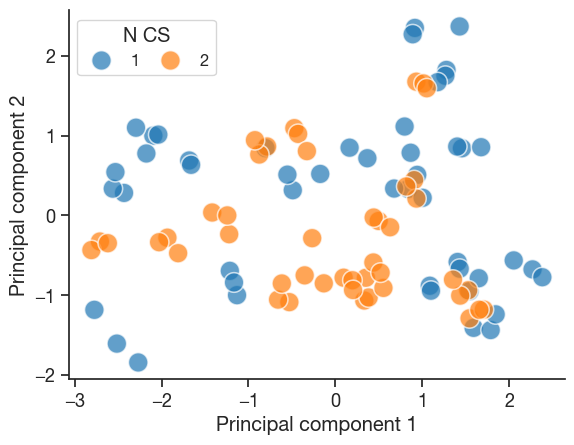

In [50]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'N CS', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,0.8), ncol=4,
                fontsize='small',  # Reduce the font size of legend labels
                # title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8
                )
# sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))
plt.savefig(figure_folder / 'PCA_n_cs.pdf')

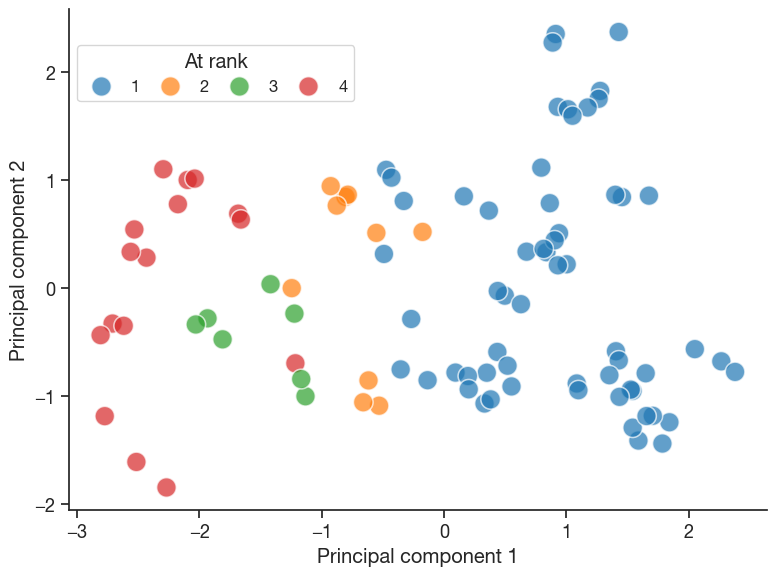

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))
g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'At rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,0.8), ncol=4,
                fontsize='small',  # Reduce the font size of legend labels
                # title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8
                )
plt.tight_layout()
plt.savefig(figure_folder / 'pca_growth_rate_rank_at.pdf')

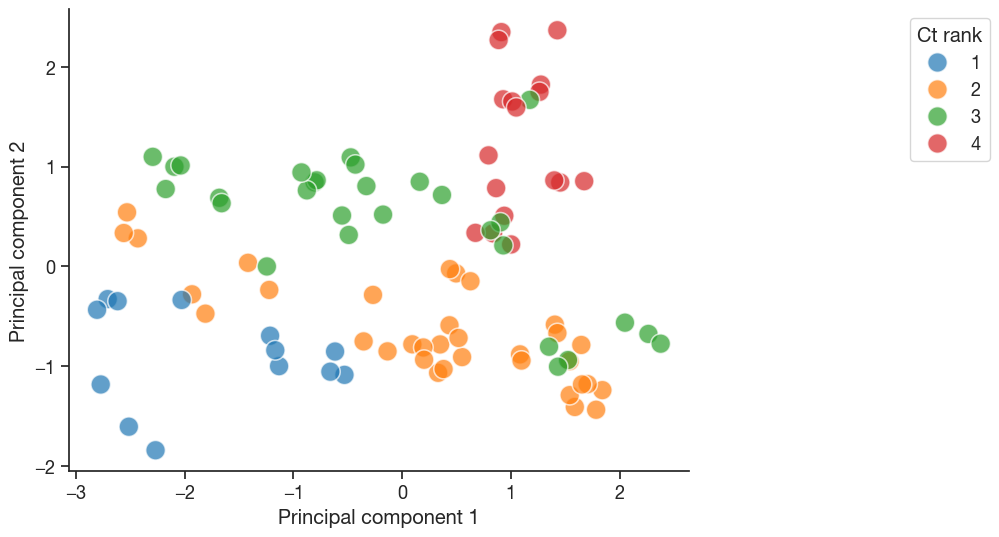

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ct rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

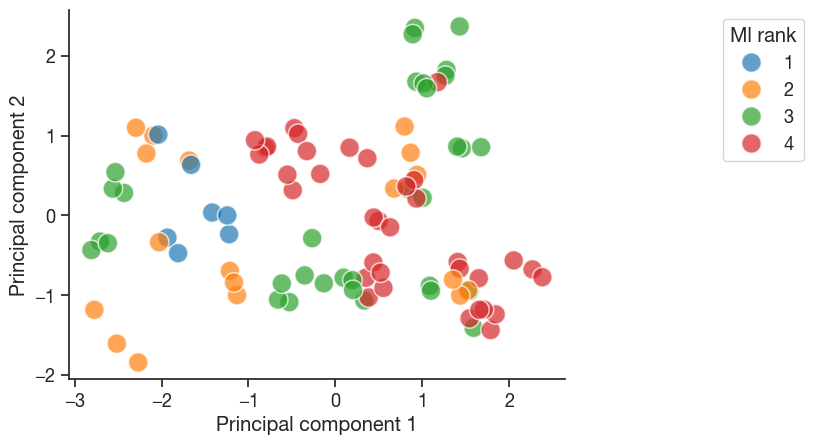

In [53]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ml rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

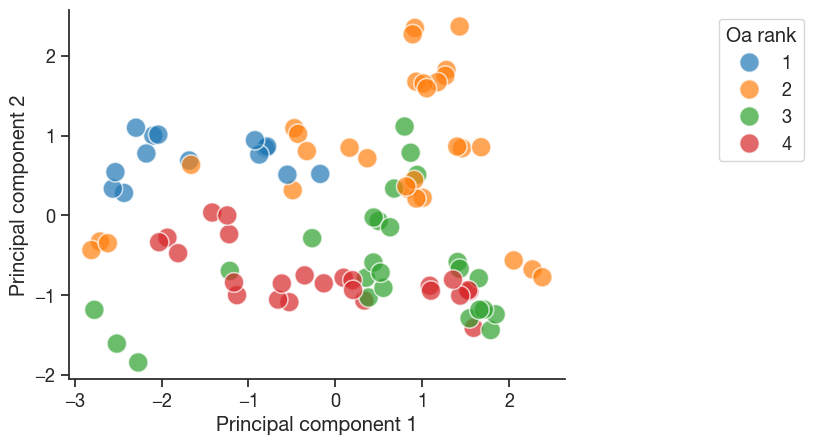

In [54]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Oa rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

In [55]:
pca_df.to_csv(data_folder / 'pca.csv')

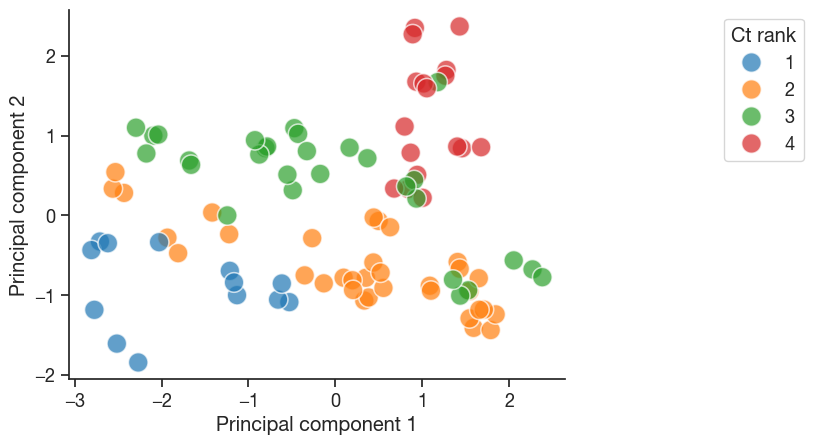

In [56]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ct rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

# Correlations

In [57]:
cfu_data_all = df.pivot(index = ['Well', 'Batch'], columns = 'Strain', values = 'CFUs/mL')
cfu_data_all.drop(index=['H10', 'H11', 'H12'], inplace=True)
cfu_data_all.reset_index()
log_cfu_all = np.log10(cfu_data_all)


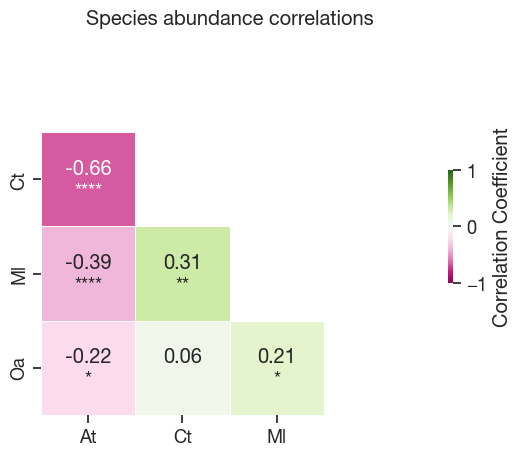

In [58]:
# Compute the correlation matrix
# Create a figure and gridspec to position the color bar
# fig, ax = plt.subplots(figsize=(6, 6))
# cbar_ax = fig.add_axes([0.6, 0.4, 0.02, 0.3])  # [left, bottom, width, height]
corr_matrix = log_cfu.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool),0)

p_matrix = pd.DataFrame(index = species_list, columns = species_list)
# Annotate with significance stars
for s1 in species_list:
    for s2 in species_list:
        r, p = st.pearsonr(log_cfu[s1], log_cfu[s2])
        # corr_dict[(s1,s2)] = r
        p_matrix.loc[s1,s2] = p

# Create significance annotation matrix
sig_matrix = p_matrix.map(lambda p: '****' if p < 0.0001 else '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Create custom annotations combining correlation values and significance
annot_matrix = corr_matrix.round(2).astype(str) + '\n' + sig_matrix


ax = sns.heatmap(corr_matrix, mask=mask, cmap='PiYG', vmin = -1, vmax = 1, cbar = True, square=True, 
            annot = annot_matrix.where(~mask,''),
            fmt = 's',
            # fmt = '.2f', 
            linewidths=0.5, linecolor='white',
            # ax=ax, 
            # cbar_ax=cbar_ax, 
            cbar_kws={'shrink':0.3, 'label': 'Correlation Coefficient', 'orientation': 'vertical'}
            )
plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  




# ax.set_xticklabels(ax.get_xticklabels())  # Exclude the last tick label
plt.title('Species abundance correlations', pad = 10)
plt.tight_layout()
plt.savefig(figure_folder / 'species_abundance_correlations.pdf', bbox_inches='tight')
plt.show()


In [59]:
df_mean78w['Carbon source'].unique()

array(['Acetate', 'Glutarate', 'Glucose', 'Citrate', 'Glycerol',
       'Glutamate', 'Inosine', 'Alanine', 'Histidine', 'Mannitol',
       'Isoleucine', 'Malate', 'Mannose', 'Ribose', 'Myo-inositol',
       'Xylose', 'Citrate + Glucose', 'Malate + Citrate',
       'Glycerol + Isoleucine', 'Glutarate + Inosine',
       'Acetate + Alanine', 'Mannitol + Acetate', 'Glutamate + Mannose',
       'Histidine + Mannose', 'Myo-inositol + Glutamate',
       'Glycerol + Inosine', 'Ribose + Glutarate', 'Xylose + Histidine',
       'Alanine + Glucose', 'Malate + Isoleucine',
       'Mannitol + Myo-inositol'], dtype=object)

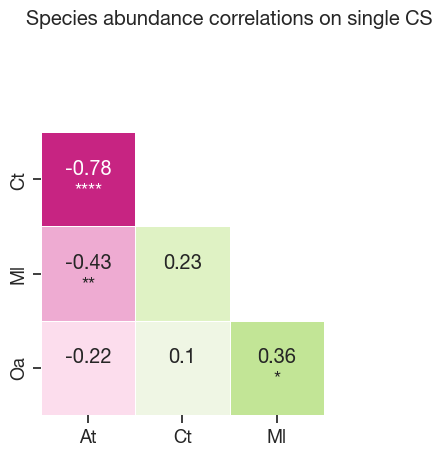

In [60]:
# Compute the correlation matrix
# Create a figure and gridspec to position the color bar
# fig, ax = plt.subplots(figsize=(6, 6))
# cbar_ax = fig.add_axes([0.6, 0.4, 0.02, 0.3])  # [left, bottom, width, height]
# corr_matrix = log_cfu_all.corr()

corr_matrix1 = log_cfu1.corr()
mask = np.triu(np.ones_like(corr_matrix1, dtype=bool),0)

p_matrix = pd.DataFrame(index = species_list, columns = species_list)
# Annotate with significance stars
for s1 in species_list:
    for s2 in species_list:
        r, p = st.pearsonr(log_cfu1[s1], log_cfu1[s2])
        # corr_dict[(s1,s2)] = r
        p_matrix.loc[s1,s2] = p

# Create significance annotation matrix
sig_matrix = p_matrix.map(lambda p: '****' if p < 0.0001 else '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Create custom annotations combining correlation values and significance
annot_matrix = corr_matrix1.round(2).astype(str) + '\n' + sig_matrix


ax = sns.heatmap(corr_matrix1, mask=mask, cmap='PiYG', vmin = -1, vmax = 1, cbar = False, square=True, 
            annot = annot_matrix.where(~mask,''),
            fmt = 's',
            # fmt = '.2f', 
            linewidths=0.5, linecolor='white',
            # ax=ax, 
            # cbar_ax=cbar_ax, cbar_kws={'shrink':0.3, 'label': 'Correlation Coefficient', 'orientation': 'vertical'}
            )
plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  




# ax.set_xticklabels(ax.get_xticklabels())  # Exclude the last tick label
plt.title('Species abundance correlations on single CS', pad = 10)
plt.tight_layout()
plt.savefig(figure_folder / 'species_abundance_correlations_1cs.pdf', bbox_inches='tight')
plt.show()


In [61]:
p_matrix

,At,Ct,Ml,Oa
At,0.0,0.0,0.002177,0.13613
Ct,0.0,0.0,0.108949,0.501922
Ml,0.002177,0.108949,0.0,0.012766
Oa,0.13613,0.501922,0.012766,0.0


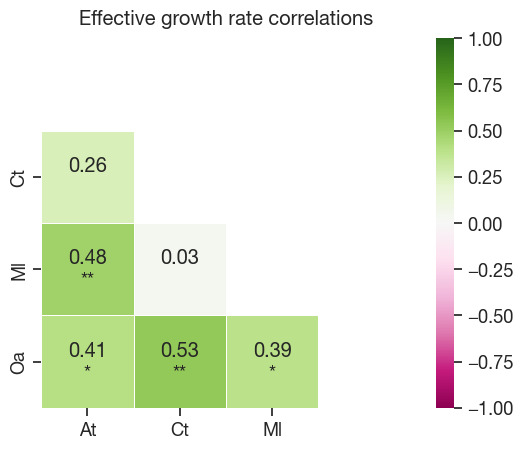

In [62]:

egr_matrix = df_mean78.pivot(index='Carbon source', columns='Species', values='Effective growth rate')
egr_corr = egr_matrix.corr()

p_matrix = pd.DataFrame(index = species_list, columns = species_list)
# Annotate with significance stars
for s1 in species_list:
    for s2 in species_list:
        r, p = st.pearsonr(egr_matrix[s1], egr_matrix[s2])
        # corr_dict[(s1,s2)] = r
        p_matrix.loc[s1,s2] = p

# Create significance annotation matrix
sig_matrix = p_matrix.map(lambda p: '****' if p < 0.0001 else '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Create custom annotations combining correlation values and significance
annot_matrix = egr_corr.round(2).astype(str) + '\n' + sig_matrix


ax = sns.heatmap(egr_corr,
            cmap='PiYG', vmin = -1, vmax = 1, square=True, 
            annot=annot_matrix.where(~mask, ''),  # Only annotate lower triangle
            fmt='',  # Use string format since we're providing custom annotations

            mask = np.triu(np.ones((4,4)),0),
            # fmt = '.2f',
            linewidths=0.5, linecolor='white',
            )

plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  
plt.title('Effective growth rate correlations', pad = 10)
plt.savefig(figure_folder / 'effective_growth_rate_correlations.pdf', bbox_inches='tight')

In [63]:
rate_df.loc[rate_df.Species=='Ct'].sort_values(by = 'Effective growth rate rank')

,Species,Carbon source,model,RSS,RMSD,bic,aic,weighted_bic,weighted_aic,y0,...,min_doubling_time,lag,Binary growth evaluation,avg_growth_rate_to_peak,r2_growth_to_peak,Yield,# CS,Effective growth rate,Growth rate rank,Effective growth rate rank
33,Ct,Acetate,Model(RichardsLag1),0.086861,0.022343,-1297.039697,-1312.834974,0.909761,0.675066,0.050437,...,2.089089,9.076544,1.0,0.152072,0.934744,1.173000,1,0.170479,1.0,1.0
13,Ct,Glutamate + Mannose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0.305470,1.0,1.0
61,Ct,Pyruvate,Model(BaranyiRoberts),0.662165,0.039151,-2763.237364,-2787.647918,0.999645,0.999954,0.046422,...,2.399552,14.022411,1.0,0.085021,0.854608,0.897467,1,0.122807,1.0,1.0
59,Ct,Phenylalanine,Model(RichardsLag1),0.105280,0.016305,-3230.182161,-3250.089232,0.549410,0.142776,0.055620,...,5.944695,22.318415,1.0,0.058215,0.947786,0.932000,1,0.061639,1.0,1.0
54,Ct,Malate,Model(Richards),0.192111,0.033228,-1164.083977,-1176.720198,0.924593,0.665241,0.001175,...,0.406212,3.130383,1.0,0.103972,0.631280,0.969000,1,0.615745,1.0,1.0
53,Ct,Leucine,Model(RichardsLag1),0.125570,0.020667,-2252.573025,-2270.990924,0.870538,0.515977,0.055218,...,3.726671,18.465121,1.0,0.088066,0.946837,1.192667,1,0.088966,1.0,1.0
52,Ct,Lactate,Model(BaranyiRoberts),0.109317,0.027553,-1004.578729,-1022.397608,0.626575,0.881055,0.047642,...,1.680708,8.985932,1.0,0.200385,0.926769,1.275333,1,0.194433,1.0,1.0
51,Ct,Isoleucine,Model(LogisticLag2),0.295598,0.025545,-3292.016119,-3312.595579,0.930282,0.630201,0.048726,...,8.991839,51.320662,1.0,0.044755,0.935367,0.998000,1,0.033681,1.0,1.0
49,Ct,Histidine,Model(LogisticLag2),0.072968,0.017437,-1916.206770,-1933.609964,0.889018,0.584312,0.050493,...,3.322169,17.982619,1.0,0.106966,0.928778,1.004667,1,0.093166,1.0,1.0
48,Ct,Glycine,Model(RichardsLag1),0.131432,0.017690,-3358.998722,-3379.199995,0.749439,0.372460,0.048112,...,5.044044,36.066296,1.0,0.051332,0.872881,0.587667,1,0.046437,1.0,1.0


Text(0.5, 1.0, 'Effective growth rate correlations 1 cs')

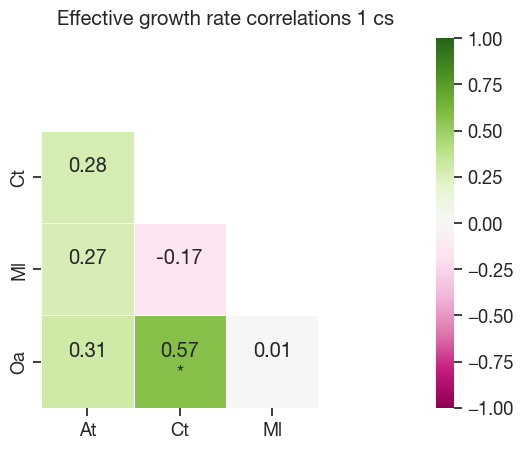

In [64]:
idx1 = df_mean78['# CS'] == 1
egr_matrix = df_mean78.loc[idx1].pivot(index='Carbon source', columns='Species', values='Effective growth rate')
egr_corr = egr_matrix.corr()

p_matrix = pd.DataFrame(index = species_list, columns = species_list)
# Annotate with significance stars
for s1 in species_list:
    for s2 in species_list:
        # r, p = st.spearmanr(egr_matrix[s1], egr_matrix[s2])
        r, p = st.pearsonr(egr_matrix[s1], egr_matrix[s2])
        # corr_dict[(s1,s2)] = r
        p_matrix.loc[s1,s2] = p

# Create significance annotation matrix
sig_matrix = p_matrix.map(lambda p: '****' if p < 0.0001 else '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Create custom annotations combining correlation values and significance
annot_matrix = egr_corr.round(2).astype(str) + '\n' + sig_matrix


ax = sns.heatmap(egr_corr,
            cmap='PiYG', vmin = -1, vmax = 1, square=True, 
            annot=annot_matrix.where(~mask, ''),  # Only annotate lower triangle
            fmt='',  # Use string format since we're providing custom annotations

            mask = np.triu(np.ones((4,4)),0),
            # fmt = '.2f',
            linewidths=0.5, linecolor='white',
            )

plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  
plt.title('Effective growth rate correlations 1 cs', pad = 10)

In [65]:
df_mean78

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank,Prediction diff
0,At,Acetate,9.333333e+08,3.932768e+08,2.0,3.0,0.095601,1.0,0.057356,3.0,3.0,1.0
1,At,Acetate + Alanine,1.400000e+09,2.828427e+08,2.0,3.0,0.228739,2.0,0.154940,3.0,3.0,1.0
2,At,Alanine,3.733333e+09,4.501851e+08,1.0,2.0,0.133138,1.0,0.097585,2.0,1.0,0.0
3,At,Alanine + Glucose,6.666667e+09,2.927570e+09,1.0,2.0,0.372152,2.0,0.278778,2.0,1.0,0.0
4,At,Citrate,1.000000e+08,3.651484e+07,4.0,4.0,0.000000,1.0,0.000000,4.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
122,Oa,Myo-inositol + Glutamate,1.533333e+08,4.320494e+07,3.0,1.0,0.613915,2.0,0.244458,3.0,3.0,0.0
124,Oa,Ribose,3.760000e+09,8.648699e+08,2.0,1.0,0.103032,1.0,0.047257,2.0,2.0,0.0
125,Oa,Ribose + Glutarate,1.500000e+08,8.648699e+07,4.0,1.0,0.414995,2.0,0.156519,2.0,2.0,-2.0
126,Oa,Xylose,5.266667e+07,1.573107e+07,2.0,2.0,0.215384,1.0,0.083993,2.0,2.0,0.0


In [66]:
df_mean78.pivot(index='Carbon source', columns='Species', values='max_growth_rate')

Species,At,Ct,Ml,Oa
Carbon source,,,,
Acetate,0.095601,0.335427,0.069082,0.227276
Acetate + Alanine,0.228739,0.361459,0.133624,0.645410
Alanine,0.133138,0.026032,0.064542,0.418134
Alanine + Glucose,0.372152,0.026032,0.188151,0.757449
Citrate,0.000000,0.116124,0.118920,0.137495
Citrate + Glucose,0.239014,0.116124,0.242528,0.476810
Glucose,0.239014,0.000000,0.123609,0.339315
Glutamate,0.204759,0.568946,0.089860,0.308978
Glutamate + Mannose,0.388057,0.568946,0.216858,0.469366


# Niche overlap

In [67]:
rate_binary = rate_df.loc[rate_df['# CS'] == 1].pivot(columns = 'Species', index = 'Carbon source', values = 'Binary growth evaluation')

In [68]:
noi_matrix = pd.DataFrame(np.zeros((4,4)), index = species_list, columns = species_list)

for i, s1 in enumerate(species_list):
    for s2 in species_list:
        noi_matrix.loc[s1,s2] = sum(rate_binary[[s1, s2]].all(axis=1))/sum(rate_binary[[s1, s2]].any(axis=1))

Text(0.5, 1.0, 'Niche overlap index')

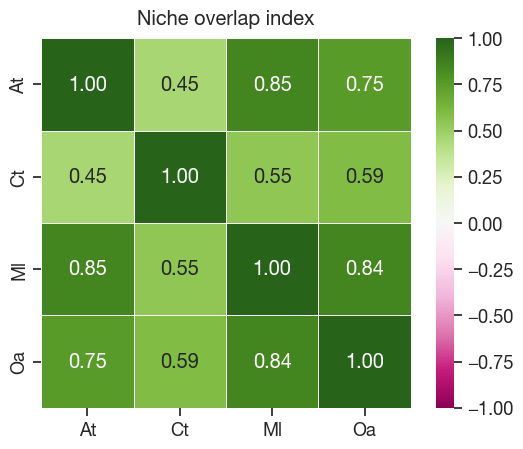

In [69]:

ax = sns.heatmap(noi_matrix,
            cmap='PiYG', vmin = -1, vmax = 1, square=True, 
            annot=True,#noi_matrix.where(~mask, ''),  # Only annotate lower triangle
            fmt='.2f',  # Use string format since we're providing custom annotations

            # mask = np.triu(np.ones((4,4)),0),
            # fmt = '.2f',
            linewidths=0.5, linecolor='white',
            )

plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks())  # Exclude the last tick
ax.set_yticks(ax.get_yticks())  
plt.title('Niche overlap index', pad = 10)

# Relative abundance

In [70]:
# Calculate relative abundances
rel_abundances = cfu_data.T / cfu_data.sum(axis=1).T
rel_abu_long = rel_abundances.T.reset_index().melt(
    id_vars='Well', 
    var_name='Species', 
    value_name='Rel. abundance'
)

In [71]:
rel_abu_long['Carbon source'] = rel_abu_long.Well.map(well_to_cs)

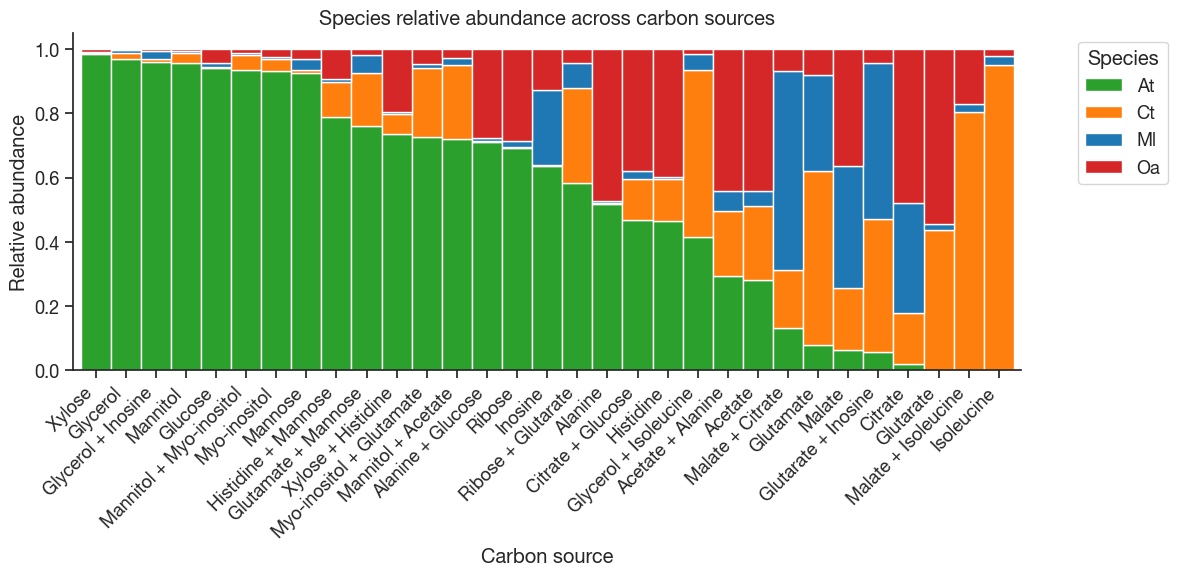

In [72]:
# Create a stacked barplot of relative abundances by carbon source
fig, ax = plt.subplots(figsize=(12, 6))

# Pivot the data to get species as columns
# rel_abu_pivot = rel_abu_long.pivot(index='Carbon source', columns='Species', values='Rel. abundance')
df_mean_pivot = df_mean78.pivot(index = 'Carbon source', columns = 'Species', values = 'Mean CFUs/mL')
# Calculate relative abundances (normalize each row to sum to 1)
df_rel_abu = df_mean_pivot.div(df_mean_pivot.sum(axis=1), axis=0)

df_rel_abu = df_rel_abu.round(3)
df_rel_abu.sort_values(by = ['At', 'Oa'],ascending = False, inplace = True)
# Create stacked bar plot
df_rel_abu[species_list].plot(kind='bar', stacked=True, ax=ax, color=palette, width=1)

plt.xlabel('Carbon source')
plt.ylabel('Relative abundance')
plt.title('Species relative abundance across carbon sources')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

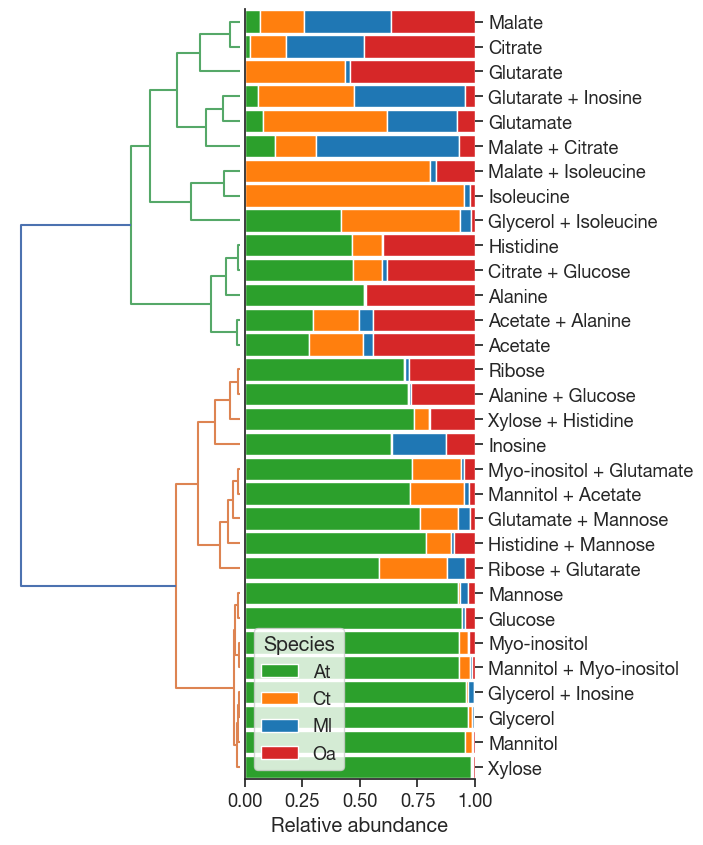

In [73]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.gridspec as gridspec

# Pivot and calculate relative abundances
df_mean_pivot = df_mean78.pivot(index='Carbon source', columns='Species', values='Mean CFUs/mL')
df_rel_abu = df_mean_pivot.div(df_mean_pivot.sum(axis=1), axis=0)

# Perform hierarchical clustering
linkage_matrix = linkage(df_rel_abu[species_list], method='ward')

# Get the dendrogram to extract order
dendro = dendrogram(linkage_matrix, no_plot=True)
clustered_order = dendro['leaves']
df_rel_abu_clustered = df_rel_abu.iloc[clustered_order]

# Create figure with custom gridspec
fig = plt.figure(figsize=(6, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 2], wspace=0.02)

# Plot dendrogram
ax1 = plt.subplot(gs[0])
dendro = dendrogram(linkage_matrix, ax=ax1, orientation='left', no_labels=True)
# ax1.set_xlabel('Distance')
# ax1.set_title('Hierarchical Clustering')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.set_yticks([])
ax1.set_xticks([])
ax1.xaxis.tick_top()  # Move x-axis ticks to top
ax1.xaxis.set_label_position('top')  # Move x-axis label to top


# Create stacked bar plot
ax2 = plt.subplot(gs[1])
df_rel_abu_clustered[species_list].plot(kind='barh', stacked=True, ax=ax2, color=palette, width=0.9)
ax2.set_ylabel('')
# ax2.xaxis.tick_top()  # Move x-axis ticks to top
# ax2.xaxis.set_label_position('top')  # Move x-axis label to top
ax2.set_xlabel('Relative abundance')
ax2.yaxis.tick_right()  # Move y-axis ticks to right
ax2.yaxis.set_label_position('right')  # Move y-axis label to right
ax2.set_xlim(0,1)
# ax2.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')

# Align dendrogram with bars
n_samples = len(df_rel_abu_clustered)
ax1.set_ylim(0, n_samples * 10)  # Match dendrogram scaling
ax2.set_ylim(-0.5, n_samples - 0.5)

sns.despine(ax=ax2)
plt.savefig(figure_folder / 'relative_abundance_with_dendrogram.pdf', bbox_inches='tight')
plt.show()

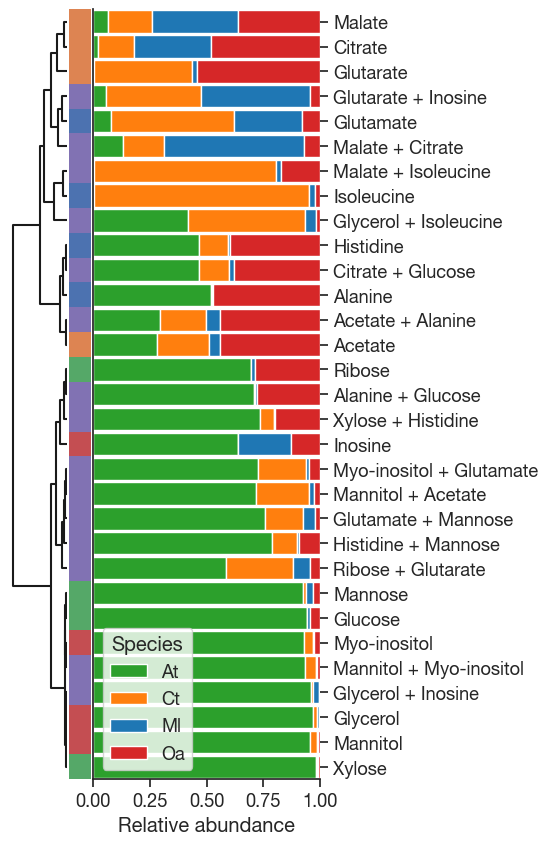

In [74]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.gridspec as gridspec

# Pivot and calculate relative abundances
df_mean_pivot = df_mean78.pivot(index='Carbon source', columns='Species', values='Mean CFUs/mL')
df_rel_abu = df_mean_pivot.div(df_mean_pivot.sum(axis=1), axis=0)

# Perform hierarchical clustering
linkage_matrix = linkage(df_rel_abu[species_list], method='ward')

# Get the dendrogram to extract order
dendro = dendrogram(linkage_matrix, no_plot=True)
clustered_order = dendro['leaves']
df_rel_abu_clustered = df_rel_abu.iloc[clustered_order]

# Create color mapping for carbon source classes
cs_classes = df_rel_abu_clustered.index.map(cs_to_class)
class_palette = {'Amino acid': 'C0', 'Organic acid': 'C1', 'Sugar': 'C2', 'Other': 'C3', 'Mix': 'C4'}
row_colors = cs_classes.map(class_palette)

# Create figure with custom gridspec - add space for color bar
fig = plt.figure(figsize=(4, 10))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 0.2, 2], wspace=0.02)

# Plot dendrogram
ax1 = plt.subplot(gs[0])
dendro = dendrogram(linkage_matrix, ax=ax1, orientation='left', no_labels=True, color_threshold=0, above_threshold_color='k')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.set_yticks([])
ax1.set_xticks([])
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')

# Add color bar for categories
ax_colors = plt.subplot(gs[1])
n_samples = len(df_rel_abu_clustered)
for i, cs in enumerate(df_rel_abu_clustered.index):
    cs_class = cs_to_class.get(cs, 'Mix')
    color = class_palette[cs_class]
    ax_colors.barh(i, 1, color=color, height=1, edgecolor='none')
ax_colors.set_ylim(-0.5, n_samples - 0.5)
ax_colors.set_xlim(0, 1)
ax_colors.axis('off')


# Create stacked bar plot
ax2 = plt.subplot(gs[2])
df_rel_abu_clustered[species_list].plot(kind='barh', stacked=True, ax=ax2, color=palette, width=0.9)
ax2.set_ylabel('')
ax2.set_xlabel('Relative abundance')
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right')
ax2.set_xlim(0,1)

# Align dendrogram with bars
ax1.set_ylim(0, n_samples * 10)
ax2.set_ylim(-0.5, n_samples - 0.5)

sns.despine(ax=ax2)
plt.savefig(figure_folder / 'relative_abundance_with_dendrogram.pdf', bbox_inches='tight')
plt.show()



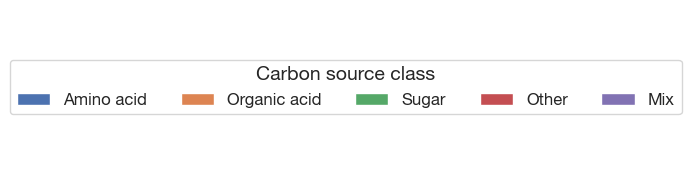

In [75]:
# Create a separate legend plot for class_palette
fig, ax = plt.subplots(figsize=(4, 2))
ax.axis('off')

# Create legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=class_palette[label], label=label) 
                   for label in class_palette.keys()]

# Create legend
ax.legend(handles=legend_elements, 
          loc='center', 
          frameon=True, 
          title='Carbon source class',
          fontsize=12,
          ncol = 5,
          title_fontsize=14)

# plt.tight_layout()
plt.savefig(figure_folder / 'carbon_source_class_legend.pdf', bbox_inches='tight')
plt.show()

# Comparison to No CS / detection limit


In [76]:
LOD = 1/5*1000 # 1 colony in 5 uL plated, converted to CFU/mL


In [118]:
no_cs_data

{'At': 672    5.146128
 673    5.342423
 674    5.342423
 768    5.681241
 769    5.602060
 770    6.079181
 Name: log10(CFUs/mL), dtype: float64,
 'Ct': 1443    4.913814
 1444    4.845098
 1445    4.944483
 1539    4.748188
 1540    4.792392
 1541    4.748188
 Name: log10(CFUs/mL), dtype: float64,
 'Ml': Series([], Name: log10(CFUs/mL), dtype: float64),
 'Oa': 2985    2.903090
 2986    3.204120
 2987    2.778151
 3081    2.602060
 3082    2.602060
 3083    3.146128
 Name: log10(CFUs/mL), dtype: float64}

In [126]:

LOD = 1/5*1000  # 1 colony in 5 uL plated, converted to CFU/mL
log_LOD = np.log10(LOD)

# Get No CS data for each strain
no_cs_data = {}
for strain in strains:
    no_cs_values = df_log.loc[(df_log['Batch'].isin([7, 8])) & 
                               (df_log['Carbon source'] == 'No CS') & 
                               (df_log['Strain'] == strain), 'log10(CFUs/mL)'].dropna()
    no_cs_data[strain] = no_cs_values

# Perform comparisons
comparison_results = []

for strain in strains:
    for cs in df_log['Carbon source'].unique():
        if cs == 'No CS':  # Skip No CS itself
            continue
            
        # Get data for this strain-carbon source combination
        cs_values = df_log.loc[(df_log['Batch'].isin([7, 8])) & 
                                (df_log['Carbon source'] == cs) & 
                                (df_log['Strain'] == strain), 'log10(CFUs/mL)'].dropna()
        
        if len(cs_values) == 0:
            continue
            
        if strain == 'Ml':
            t_stat, p_value = st.ttest_1samp(cs_values, log_LOD, alternative='greater')
            mean_no_cs = log_LOD
        else:
            t_stat, p_value = st.ttest_ind(cs_values, no_cs_data[strain], 
                                        equal_var=False, alternative='two-sided')
            mean_no_cs = no_cs_data[strain].mean()

        comparison_results.append({
            'Species': strain,
            'Carbon source': cs,
            'Mean log10(CFUs/mL)': cs_values.mean(),
            'Std log10(CFUs/mL)': cs_values.std(),
            'N samples': len(cs_values),
            'Detected': is_detected,
            'Comparison type': comparison_type,
            'Reference mean': mean_no_cs,
            't-statistic': t_stat,
            'p-value': p_value,
            'Significant (p<0.05)': p_value < 0.05 if not np.isnan(p_value) else False
        })

comparison_df = pd.DataFrame(comparison_results)

# Add multiple testing correction
from statsmodels.stats.multitest import multipletests

valid_pvals = comparison_df['p-value'].notna()
comparison_df['Adjusted p-value'] = np.nan
if valid_pvals.sum() > 0:
    _, adj_pvals, _, _ = multipletests(comparison_df.loc[valid_pvals, 'p-value'], 
                                       method='fdr_bh', alpha=0.05)
    comparison_df.loc[valid_pvals, 'Adjusted p-value'] = adj_pvals

comparison_df['Significant (adj. p<0.05)'] = comparison_df['Adjusted p-value'] < 0.05

# Save results
# comparison_df.to_csv(data_folder / 'abundance_vs_control_statistics.csv', index=False)

# Display summary
print(f"Total comparisons: {len(comparison_df)}")
print(f"Detected conditions: {comparison_df['Detected'].sum()}")
print(f"Significant (p<0.05): {comparison_df['Significant (p<0.05)'].sum()}")
print(f"Significant (adjusted p<0.05): {comparison_df['Significant (adj. p<0.05)'].sum()}")

comparison_df.loc[comparison_df['Significant (adj. p<0.05)']].sort_values(by=['p-value'], ascending =False)

Total comparisons: 124
Detected conditions: 124
Significant (p<0.05): 124
Significant (adjusted p<0.05): 124


,Species,Carbon source,Mean log10(CFUs/mL),Std log10(CFUs/mL),N samples,Detected,Comparison type,Reference mean,t-statistic,p-value,Significant (p<0.05),Adjusted p-value,Significant (adj. p<0.05)
9,At,Isoleucine,6.695071,0.360372,6,True,vs No CS,5.532243,5.822136,1.726326e-04,True,1.726326e-04,True
29,At,Malate + Isoleucine,6.834092,0.069617,6,True,vs No CS,5.532243,9.431401,1.418554e-04,True,1.430087e-04,True
3,At,Glutarate,6.929260,0.333829,6,True,vs No CS,5.532243,7.280567,2.662353e-05,True,2.705998e-05,True
46,Ct,Ribose,7.023439,0.283452,6,True,vs No CS,4.832027,18.159902,2.217952e-06,True,2.272943e-06,True
32,Ct,Glucose,7.279742,0.286319,6,True,vs No CS,4.832027,20.096826,1.270268e-06,True,1.312611e-06,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,Ct,Glutarate + Inosine,9.346379,0.095836,6,True,vs No CS,4.832027,86.847641,1.650206e-15,True,3.512177e-14,True
31,Ct,Acetate,8.877731,0.083262,6,True,vs No CS,4.832027,83.875307,1.420674e-15,True,3.512177e-14,True
54,Ct,Mannitol + Acetate,8.880155,0.081034,6,True,vs No CS,4.832027,85.048152,1.276001e-15,True,3.512177e-14,True
40,Ct,Isoleucine,9.826966,0.099838,6,True,vs No CS,4.832027,93.853327,1.087419e-15,True,3.512177e-14,True


<Axes: xlabel='Rel. abundance', ylabel='Density'>

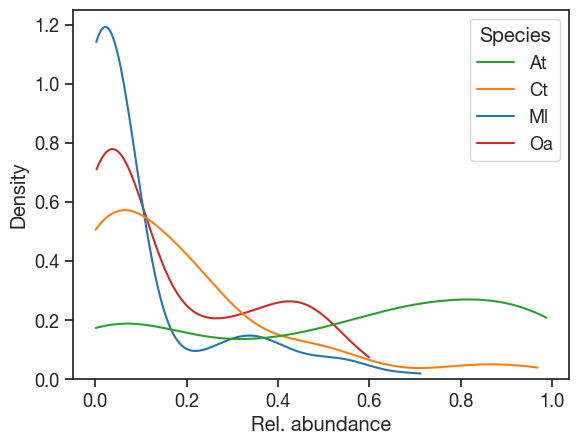

In [77]:
sns.kdeplot(rel_abu_long, x = 'Rel. abundance', hue = 'Species', hue_order=species_list, palette = palette, cut = 0)
# plt.yscale('log')

<Axes: xlabel='lag', ylabel='max_growth_rate'>

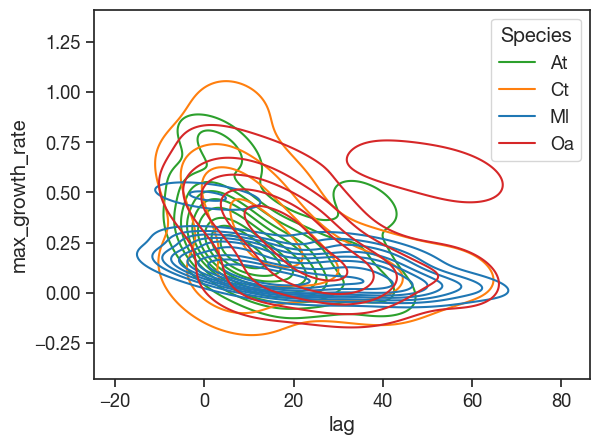

In [78]:
sns.kdeplot(rate_df, x = 'lag', y = 'max_growth_rate', hue = 'Species', hue_order = species_list, palette=palette)

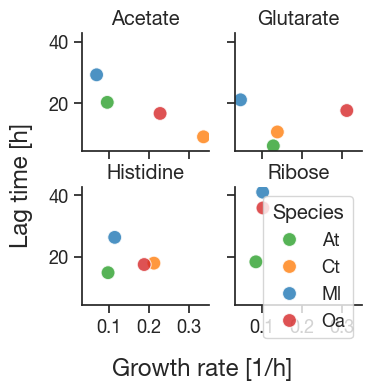

In [79]:
four_cs = ['Acetate', 'Glutarate', 'Histidine', 'Ribose']
fig, axes = plt.subplots(2,2, figsize = (4,4), sharex=True, sharey = True)
axes = axes.flatten()
for i, cs in enumerate(four_cs):
    ax = axes[i]
    idxcs = rate_df['Carbon source'] == cs
    if i == 3:
        legend=True
    else:
        legend = False
    ax.set_title(cs)
    sns.scatterplot(rate_df.loc[idxcs], x = 'max_growth_rate', y = 'lag', ax = ax, hue = 'Species',
                    s = 100,
                    alpha = 0.8,
                    palette = palette, hue_order = species_list, legend = legend)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.supxlabel('Growth rate [1/h]')
fig.supylabel('Lag time [h]')
plt.subplots_adjust(left = 0.2, bottom=0.2, hspace = 0.3, wspace=0.2)
sns.despine()
# plt.savefig()

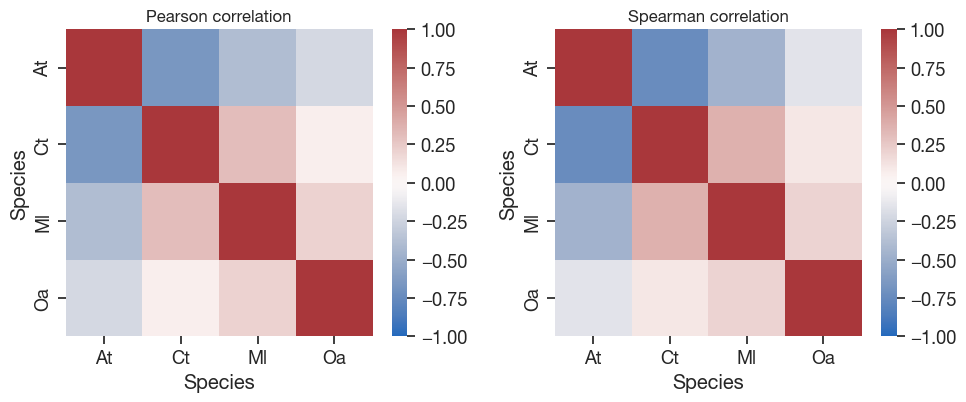

In [80]:
fig, axes = plt.subplots(1,2, figsize = (10,4))
sns.heatmap(log_cfu.corr(), cmap='vlag', vmin = -1, vmax = 1, ax = axes[0], cbar = True, square=True,)
sns.heatmap(log_cfu.corr(method = 'spearman'), cmap='vlag', vmin = -1, vmax = 1, ax = axes[1], square=True)
axes[0].set_title('Pearson correlation', size = 12)
axes[1].set_title('Spearman correlation', size = 12)
plt.tight_layout()

In [81]:
pca_mean = pca_df.groupby('Carbon source').mean(['Principal component 1',	'Principal component 2'])
pca_mean['N CS'] = [2 if '+' in x else 1 for x in pca_mean.index]

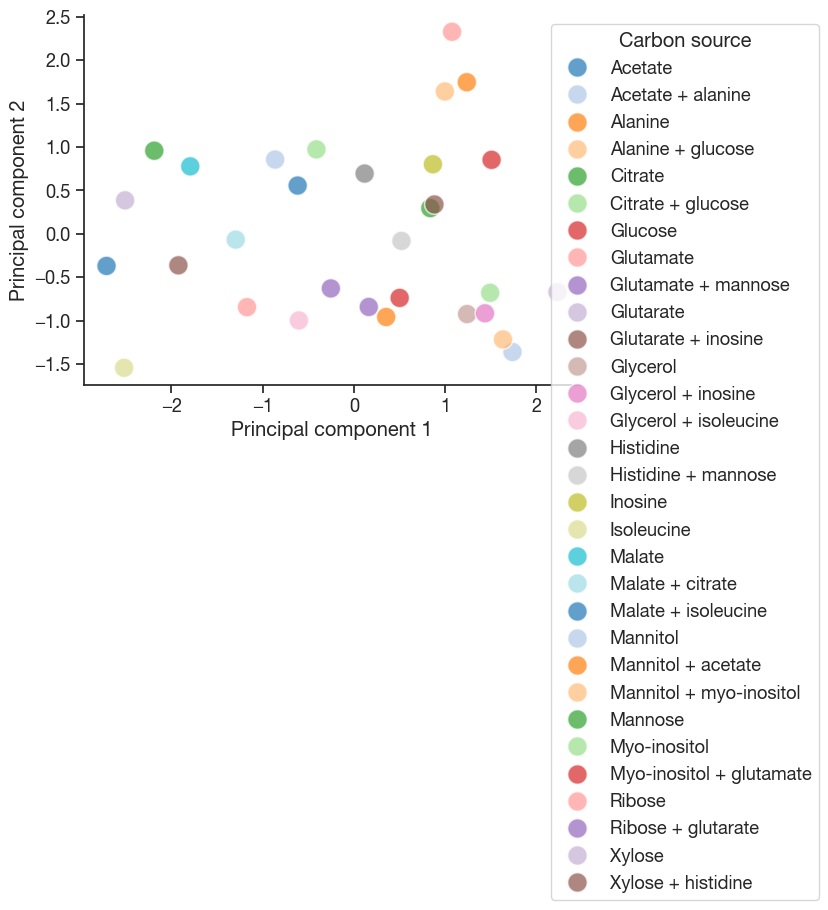

In [82]:

g = sns.scatterplot(pca_mean, x = 'Principal component 1', y = 'Principal component 2', hue = 'Carbon source', s = 200, alpha = 0.7, 
                    palette = 'tab20'
                    )
sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))